In [ ]:
 Data Mining Full Project
Market Basket Analysis using Association Rules (Apriori)
1️⃣ Project Objective (គោលបំណង)
គម្រោងនេះមានគោលបំណង៖
•	ស្វែងរក ទំនាក់ទំនងរវាងផលិតផល
•	រក Pattern ថា product ណាដែលទិញជាមួយគ្នា
•	ជួយអាជីវកម្ម Increase Sales
ឧទាហរណ៍
Customer ទិញ
Bread → Butter
Milk → Cereal
Beer → Chips
អាជីវកម្មអាចធ្វើ
•	Product recommendation
•	Store layout optimization
•	Promotion bundle
នេះគឺជាការប្រើប្រាស់ Data Mining ក្នុង Business Intelligence


In [2]:
# 2️⃣ Import Libraries
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
# ពន្យល់
# •	pandas → គ្រប់គ្រង dataset
# •	apriori → រក frequent itemsets
# •	association_rules → រក relationship rules


In [3]:
# 3️⃣ Create Transaction Dataset
# ឧទាហរណ៍ supermarket data
data = {

"Bread":[1,1,0,1,1],
"Milk":[1,1,1,0,1],
"Butter":[1,0,0,1,1],
"Beer":[0,1,1,1,0],
"Chips":[0,1,1,1,0]

}

df = pd.DataFrame(data)

df
# Dataset មាន
# Transaction	Bread	Milk	Butter	Beer	Chips
# 1	1	1	1	0	0
# 2	1	1	0	1	1
# 3	0	1	0	1	1
# 4	1	0	1	1	1
# 5	1	1	1	0	0
# 1 = customer buy
# 0 = customer not buy


,Bread,Milk,Butter,Beer,Chips
0,1,1,1,0,0
1,1,1,0,1,1
2,0,1,0,1,1
3,1,0,1,1,1
4,1,1,1,0,0


In [4]:
# 4️⃣ Data Mining Step: Frequent Itemsets
frequent_items = apriori(df, min_support=0.4, use_colnames=True)

frequent_items
# ពន្យល់
# Support = តើ product combination កើតឡើងប៉ុន្មាន %
# ឧទាហរណ៍
# Itemset	Support
# Bread	0.8
# Milk	0.8
# Beer	0.6
# Milk,Bread	0.6
# មានន័យថា
# Bread មានក្នុង 80% transactions


/opt/anaconda3/lib/python3.13/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.8,(Bread)
1,0.8,(Milk)
2,0.6,(Butter)
3,0.6,(Beer)
4,0.6,(Chips)
5,0.6,"(Milk, Bread)"
6,0.6,"(Butter, Bread)"
7,0.4,"(Beer, Bread)"
8,0.4,"(Chips, Bread)"
9,0.4,"(Butter, Milk)"


In [5]:
# 5️⃣ Generate Association Rules
rules = association_rules(
    frequent_items,
    metric="confidence",
    min_threshold=0.6
)

rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Bread),(Milk),0.8,0.8,0.6,0.750000,0.937500,1.0,-0.04,0.8,-0.250000,0.600000,-0.250000,0.750000
1,(Milk),(Bread),0.8,0.8,0.6,0.750000,0.937500,1.0,-0.04,0.8,-0.250000,0.600000,-0.250000,0.750000
2,(Butter),(Bread),0.6,0.8,0.6,1.000000,1.250000,1.0,0.12,inf,0.500000,0.750000,1.000000,0.875000
3,(Bread),(Butter),0.8,0.6,0.6,0.750000,1.250000,1.0,0.12,1.6,1.000000,0.750000,0.375000,0.875000
4,(Beer),(Bread),0.6,0.8,0.4,0.666667,0.833333,1.0,-0.08,0.6,-0.333333,0.400000,-0.666667,0.583333
5,(Chips),(Bread),0.6,0.8,0.4,0.666667,0.833333,1.0,-0.08,0.6,-0.333333,0.400000,-0.666667,0.583333
6,(Butter),(Milk),0.6,0.8,0.4,0.666667,0.833333,1.0,-0.08,0.6,-0.333333,0.400000,-0.666667,0.583333
7,(Beer),(Milk),0.6,0.8,0.4,0.666667,0.833333,1.0,-0.08,0.6,-0.333333,0.400000,-0.666667,0.583333
8,(Chips),(Milk),0.6,0.8,0.4,0.666667,0.833333,1.0,-0.08,0.6,-0.333333,0.400000,-0.666667,0.583333
9,(Beer),(Chips),0.6,0.6,0.6,1.000000,1.666667,1.0,0.24,inf,1.000000,1.000000,1.000000,1.000000


In [ ]:
# 6️⃣ Result Interpretation
# ឧទាហរណ៍ Output
# Antecedent	Consequent	Support	Confidence	Lift
# Bread	Butter	0.6	0.75	1.2
# Beer	Chips	0.6	1.0	1.5
# ពន្យល់
# Rule Example
# Bread → Butter
# មានន័យថា
# Customer ដែលទិញ Bread
# 75% នឹងទិញ Butter ផងដែរ


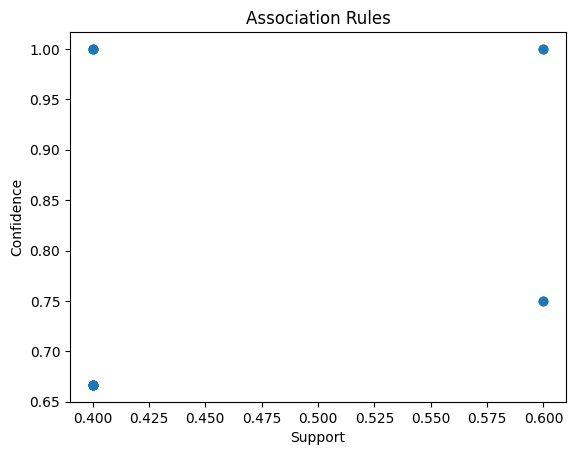

In [6]:
# 7️⃣ Meaning of Metrics
# 1️⃣ Support
# Support = ការកើតឡើងក្នុង dataset
# Support(Bread,Butter) = 3 / 5 = 0.6
# 2️⃣ Confidence
# Confidence = Probability
# Confidence = P(Butter | Bread)
# មានន័យ
# Customer ទិញ Bread
# មាន chance 75% ទិញ Butter
# 3️⃣ Lift
# Lift បង្ហាញថា relationship ខ្លាំងប៉ុន្មាន
# Lift > 1 → strong relationship
# Lift = 1 → no relationship
# Lift < 1 → weak relationship
# 8️⃣ Business Insight (Knowledge Discovery)
# Data Mining រកឃើញ
# Pattern 1
# Bread → Butter
# 👉 ដាក់ product នៅជិតគ្នា
# Pattern 2
# Beer → Chips
# 👉 Promotion bundle
# Buy Beer + Chips → Discount
# 9️⃣ Visualization (Optional)
import matplotlib.pyplot as plt

plt.scatter(
    rules['support'],
    rules['confidence']
)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules")
plt.show()
# 🔟 Role in Big Data Intelligence
# Data Mining ជួយ
# ✔️ Discover hidden product relationships
# ✔️ Improve marketing strategy
# ✔️ Increase cross-selling
# ✔️ Support decision making
